In [ ]:
!pip install torch_geometric
!pip install pyg_lib torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.4.0+cu121.html

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 24.5 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.4.0+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 14.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 26.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 24.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 22.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 986.2/986.2 kB 25.6 MB/s eta 0:00:00


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv  # Import GCNConv
from sklearn.metrics import f1_score  # To calculate F1 score
import numpy as np
import matplotlib.pyplot as plt

# Load the Cora dataset
dataset = Planetoid(root='/tmp/Cora', name='Cora')
data = dataset[0]

# Define the MLP for edge probability
class EdgeProbMLP(nn.Module):
    def __init__(self, in_channels, hidden_dim):
        super(EdgeProbMLP, self).__init__()
        self.fc1 = nn.Linear(2 * in_channels, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, node_features, edge_index):
        edge_features = torch.cat([node_features[edge_index[0]], node_features[edge_index[1]]], dim=1)
        x = F.relu(self.fc1(edge_features))
        prob = torch.sigmoid(self.fc2(x))
        return prob

# Define the overall model with Edge Probabilities and GCNConv (GNN)
class GNNModel(nn.Module):
    def __init__(self, in_channels, hidden_dim, out_channels, num_classes):
        super(GNNModel, self).__init__()
        self.edge_prob_mlp = EdgeProbMLP(in_channels, hidden_dim)
        self.gcn1 = GCNConv(in_channels, hidden_dim)
        self.gcn2 = GCNConv(hidden_dim, num_classes)

    def forward(self, data, edge_index):
        # Forward pass through two layers of GCNConv with the given edges
        x = F.relu(self.gcn1(data.x, edge_index))
        out = self.gcn2(x, edge_index)
        return out

# Gumbel-Softmax trick for edge sampling
def gumbel_softmax_sampling(edge_probs, edge_index, q=500):
    gumbels = -torch.empty_like(edge_probs).exponential_().log()  # Sample from Gumbel(0, 1)
    logits = (edge_probs + gumbels) / 0.5  # Temperature parameter tau=0.5
    samples = F.softmax(logits, dim=-1)
    sampled_edges = torch.multinomial(samples, q, replacement=False)
    return sampled_edges

# F1 score calculation helper
def calculate_f1(logits, labels, mask):
    preds = logits[mask].argmax(dim=1)
    f1 = f1_score(labels[mask].cpu(), preds.cpu(), average='micro')
    return f1

# Training function (uses sampled edges)
def train(model, data, optimizer, criterion, q=500):
    model.train()
    optimizer.zero_grad()

    # Compute edge probabilities
    edge_probs = model.edge_prob_mlp(data.x, data.edge_index).squeeze()

    # Sample edges using the Gumbel-Softmax trick
    sampled_edge_indices = gumbel_softmax_sampling(edge_probs, data.edge_index, q=q)
    sampled_edge_index = data.edge_index[:, sampled_edge_indices]

    # Forward pass with sampled edges
    out = model(data, sampled_edge_index)

    # Compute node classification loss
    loss = criterion(out[data.train_mask], data.y[data.train_mask])

    # Backpropagate loss
    loss.backward()

    # Accumulate gradients and update parameters
    optimizer.step()

    return loss.item()

# Evaluation function (uses full graph)
def evaluate(model, data):
    model.eval()
    with torch.no_grad():
        # Use the full graph's edge_index for evaluation (no sampling)
        out = model(data, data.edge_index)

    # Calculate F1 scores for train, val, and test sets
    train_f1 = calculate_f1(out, data.y, data.train_mask)
    val_f1 = calculate_f1(out, data.y, data.val_mask)
    test_f1 = calculate_f1(out, data.y, data.test_mask)

    return train_f1, val_f1, test_f1

# Main training loop
# device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
# data = data.to(device)
# optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
# criterion = nn.CrossEntropyLoss()

# for epoch in range(200):
#     loss = train(model, data, optimizer, criterion, q=2000)
#     train_f1, val_f1, test_f1 = evaluate(model, data)

#     print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

In [ ]:
# @title Main

Epoch 0, Loss: 1.9515, Train F1: 0.9429, Val F1: 0.5960, Test F1: 0.6330
Epoch 1, Loss: 1.4433, Train F1: 0.9643, Val F1: 0.6740, Test F1: 0.7090
Epoch 2, Loss: 1.0036, Train F1: 0.9714, Val F1: 0.7080, Test F1: 0.7330
Epoch 3, Loss: 0.6805, Train F1: 0.9786, Val F1: 0.7240, Test F1: 0.7450
Epoch 4, Loss: 0.3774, Train F1: 0.9714, Val F1: 0.7300, Test F1: 0.7560
Epoch 5, Loss: 0.2502, Train F1: 0.9714, Val F1: 0.7360, Test F1: 0.7620
Epoch 6, Loss: 0.1468, Train F1: 0.9714, Val F1: 0.7340, Test F1: 0.7660
Epoch 7, Loss: 0.1521, Train F1: 0.9786, Val F1: 0.7480, Test F1: 0.7720
Epoch 8, Loss: 0.0863, Train F1: 0.9786, Val F1: 0.7560, Test F1: 0.7800
Epoch 9, Loss: 0.1006, Train F1: 0.9857, Val F1: 0.7700, Test F1: 0.7840
Epoch 10, Loss: 0.0459, Train F1: 0.9929, Val F1: 0.7720, Test F1: 0.7840
Epoch 11, Loss: 0.1247, Train F1: 0.9786, Val F1: 0.7660, Test F1: 0.7840
Epoch 12, Loss: 0.0374, Train F1: 0.9714, Val F1: 0.7320, Test F1: 0.7630
Epoch 13, Loss: 0.0632, Train F1: 0.9571, Val F1

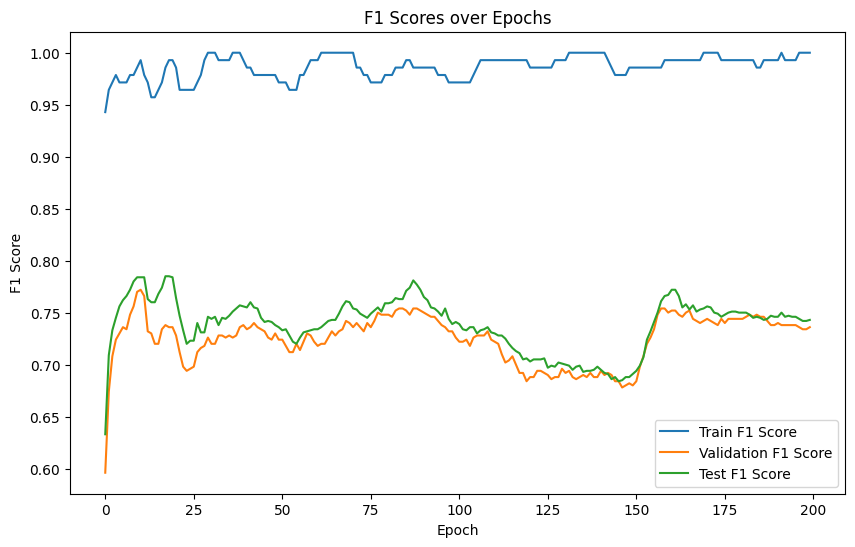

In [ ]:
# Main training loop
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = GNNModel(in_channels=dataset.num_node_features, hidden_dim=128, out_channels=64, num_classes=dataset.num_classes).to(device)
data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

NUM_EPOCHS = 200

train_f1_scores = np.zeros(NUM_EPOCHS)
val_f1_scores = np.zeros(NUM_EPOCHS)
test_f1_scores = np.zeros(NUM_EPOCHS)

best_test_f1 = 0

for epoch in range(NUM_EPOCHS):
    loss = train(model, data, optimizer, criterion, q=500)
    train_f1, val_f1, test_f1 = evaluate(model, data)

    # Store the F1 scores
    train_f1_scores[epoch] = train_f1
    val_f1_scores[epoch] = val_f1
    test_f1_scores[epoch] = test_f1

    # Update the best test F1 score
    if test_f1 > best_test_f1:
        best_test_f1 = test_f1

    print(f'Epoch {epoch}, Loss: {loss:.4f}, Train F1: {train_f1:.4f}, Val F1: {val_f1:.4f}, Test F1: {test_f1:.4f}')

# Print the best test F1 score
print(f'Best Test F1 Score: {best_test_f1:.4f}')

# Plot the F1 scores
plt.figure(figsize=(10, 6))
plt.plot(train_f1_scores, label='Train F1 Score')
plt.plot(val_f1_scores, label='Validation F1 Score')
plt.plot(test_f1_scores, label='Test F1 Score')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('F1 Scores over Epochs')
plt.legend()
plt.show()
